### Kernels and responses for clusters — outlier filtering evaluation

Pulled from `figure_5_supplemental.ipynb`. Purpose: compare how the two different outlier-removal methods used by `plot_mean_cluster_response_profiles` and `plot_cluster_properties_combined` affect which cells are included and how the plots look.

Plots included: kernel weights for clusters, kernel heatmaps, `plot_cluster_properties_combined`, and `plot_mean_cluster_response_profiles`.

## Data Loading

#### Imports & setup

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use("Agg")  # non-interactive backend
import matplotlib.pyplot as plt
import pickle
import seaborn as sns
import scipy.stats as stats
from scipy.special import comb

import visual_behavior.data_access.loading as loading
import visual_behavior.data_access.utilities as utilities
import visual_behavior.visualization.utils as utils

from visual_behavior.dimensionality_reduction.clustering import plotting
from visual_behavior.dimensionality_reduction.clustering import processing

import visual_behavior.visualization.ophys.platform_paper_figures as ppf
import visual_behavior.visualization.ophys.platform_single_cell_examples as pse

%load_ext autoreload
%autoreload 2
%matplotlib inline

ERROR:tornado.general:Uncaught exception in ZMQStream callback
Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 632, in get
    value = obj._trait_values[self.name]
KeyError: '_control_lock'

During handling of the above exception, another exception occurred:

Traceback (most recent call last):
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/zmq/eventloop/zmqstream.py", line 565, in _log_error
    f.result()
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/ipykernel/kernelbase.py", line 301, in dispatch_control
    async with self._control_lock:
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.py", line 687, in __get__
    return t.cast(G, self.get(obj, cls))  # the G should encode the Optional
  File "/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/traitlets/traitlets.p

In [2]:
sns.set_context('notebook', font_scale=1.5, rc={'lines.markeredgewidth': 1})

experience_level_colors = utils.get_experience_level_colors()
cre_line_colors = utils.get_cre_line_colors()
experience_levels = utils.get_new_experience_levels()
cell_types = utils.get_cell_types()

glm_version = '24_events_all_L2_optimize_by_session'

# Main clustering parameters
n_clusters = 14
n_clusters_familiar = 10  # For familiar-only clustering control

# Create save directories
save_dir = os.path.join(loading.get_figures_save_dir(), 'platform_paper_figures', 'figure_5_supplemental')
if not os.path.exists(save_dir):
    os.makedirs(save_dir)

#### Metadata tables

In [3]:
# Cache directory
platform_cache_dir = loading.get_platform_analysis_cache_dir()

# Curated metadata tables
metadata_tables_dir = loading.get_metadata_tables_dir()
experiments_table = pd.read_csv(os.path.join(metadata_tables_dir, "all_ophys_experiments_table.csv"), index_col=0)
platform_experiments = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_ophys_experiments_table.csv"), index_col=0)
platform_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_ophys_cells_table.csv"), index_col=0)
matched_cells_table = pd.read_csv(os.path.join(metadata_tables_dir, "platform_paper_matched_ophys_cells_table.csv"), index_col=0)

# Relevant IDs
matched_cells = matched_cells_table.cell_specimen_id.unique()
matched_experiments = matched_cells_table.ophys_experiment_id.unique()

# Cre lines, cell types, and palette for plotting
cre_lines = np.sort(platform_cells_table.cre_line.unique())
cell_types = utils.get_cell_types()
experience_levels = utils.get_experience_levels()
palette = utils.get_experience_level_colors()


#### GLM & clustering results

In [4]:
data_dir = loading.get_clustering_results_dir()

# Load clustering results (main clustering with n_clusters=14)
feature_matrix = pd.read_hdf(os.path.join(data_dir, 'clustering_feature_matrix.h5'), key='df')
feature_matrix = feature_matrix.rename(columns={'all-images': 'images', 'behavioral': 'behavior'})

cluster_meta = pd.read_hdf(os.path.join(data_dir, 'cluster_metadata_' + str(n_clusters) + '_clusters.h5'), key='df')

original_feature_matrix = feature_matrix.copy()
original_cluster_meta = cluster_meta.copy()

cluster_order = np.sort(cluster_meta.cluster_id.unique())

# Load GLM results for coding score analysis
glm_results_dir = loading.get_glm_results_dir()
results_pivoted = pd.read_hdf(os.path.join(glm_results_dir, 'across_session_normalized_platform_results_pivoted.h5'), key='df')

# Get GLM weights
weights_df = pd.read_hdf(os.path.join(loading.get_glm_results_dir(), 'platform_results_weights_df.h5'), key='df')
weights_df['experience_level'] = [utils.convert_experience_level(experience_level) for experience_level in weights_df.experience_level.values]
weights_df = weights_df.merge(platform_experiments[['cell_type']], on='ophys_experiment_id', how='left')
weights_df = weights_df.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id', how='left')

run_params = pd.read_pickle(os.path.join(loading.get_glm_results_dir(), glm_version + '_run_params.pkl'))
kernels = run_params['kernels']



#### Multi-Session Dataframes

In [5]:
# Data type configuration
data_type = 'events'
interpolate = True
output_sampling_rate = 30
inclusion_criteria = 'platform_experiment_table'


conditions = ['cell_specimen_id', 'is_change']
multi_session_df = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

# Separate into change and non-change responses
change_mdf = multi_session_df[multi_session_df.is_change == True]
change_mdf = change_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

image_mdf = multi_session_df[multi_session_df.is_change == False]
image_mdf = image_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# Omission responses
conditions = ['cell_specimen_id', 'omitted']
omission_mdf = loading.get_multi_session_df_for_conditions(
    data_type,
    event_type='all',
    conditions=conditions,
    inclusion_criteria=inclusion_criteria,
    interpolate=interpolate,
    output_sampling_rate=output_sampling_rate,
    epoch_duration_mins=None)

omission_mdf = omission_mdf[omission_mdf.omitted == True]
omission_mdf = omission_mdf.merge(cluster_meta.reset_index()[['cell_specimen_id', 'cluster_id']], on='cell_specimen_id')

# # Remove outliers
# threshold_percentile = 99.8  # for removing outliers for pl
# image_mdf, image_outliers = processing.remove_outliers(image_mdf, threshold_percentile)
# change_mdf, change_outliers = processing.remove_outliers(change_mdf, threshold_percentile)
# omission_mdf, omission_outliers = processing.remove_outliers(omission_mdf, threshold_percentile)

/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_is_change_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_is_change_platform_experiment_table.feather
there are 1881 experiments in the full multi_session_df
there are 400 experiments in the multi_session_df after limiting to platform experiments
there are 400 experiments after filtering for inclusion criteria -  platform_experiment_table


/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/boto3/compat.py:89: PythonDeprecationWarning: Boto3 will no longer support Python 3.9 starting April 29, 2026. To continue receiving service updates, bug fixes, and security updates please upgrade to Python 3.10 or later. More information can be found here: https://aws.amazon.com/blogs/developer/python-support-policy-updates-for-aws-sdks-and-tools/
  warnings.warn(warning, PythonDeprecationWarning)
/opt/miniconda3/envs/visual_behavior_sdk/lib/python3.9/site-packages/allensdk/brain_observatory/behavior/behavior_project_cache/behavior_project_cache.py:135: UpdatedStimulusPresentationTableWarning: 
	As of AllenSDK version 2.16.0, the latest Visual Behavior Ophys data has been significantly updated from previous releases. Specifically the user will need to update all processing of the stimulus_presentations tables. These tables now include multiple stimulus types delineated by the columns `stimulus_block` and `stimulus_bl

1936
loading files from /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs
mean_response_df_events_all_omitted_platform_experiment_table.pkl
loading multi_session_df from saved feather file at /Users/marinag/Library/CloudStorage/Dropbox/JupyterNotebooks/FinalDataAssetsforCodeOcean/visual_behavior_ophys_multi_session_dfs/mean_response_df_events_all_omitted_platform_experiment_table.feather
there are 1879 experiments in the full multi_session_df
there are 401 experiments in the multi_session_df after limiting to platform experiments
there are 401 experiments after filtering for inclusion criteria -  platform_experiment_table


## Kernel weights for clusters

All cells (no cell-type split):

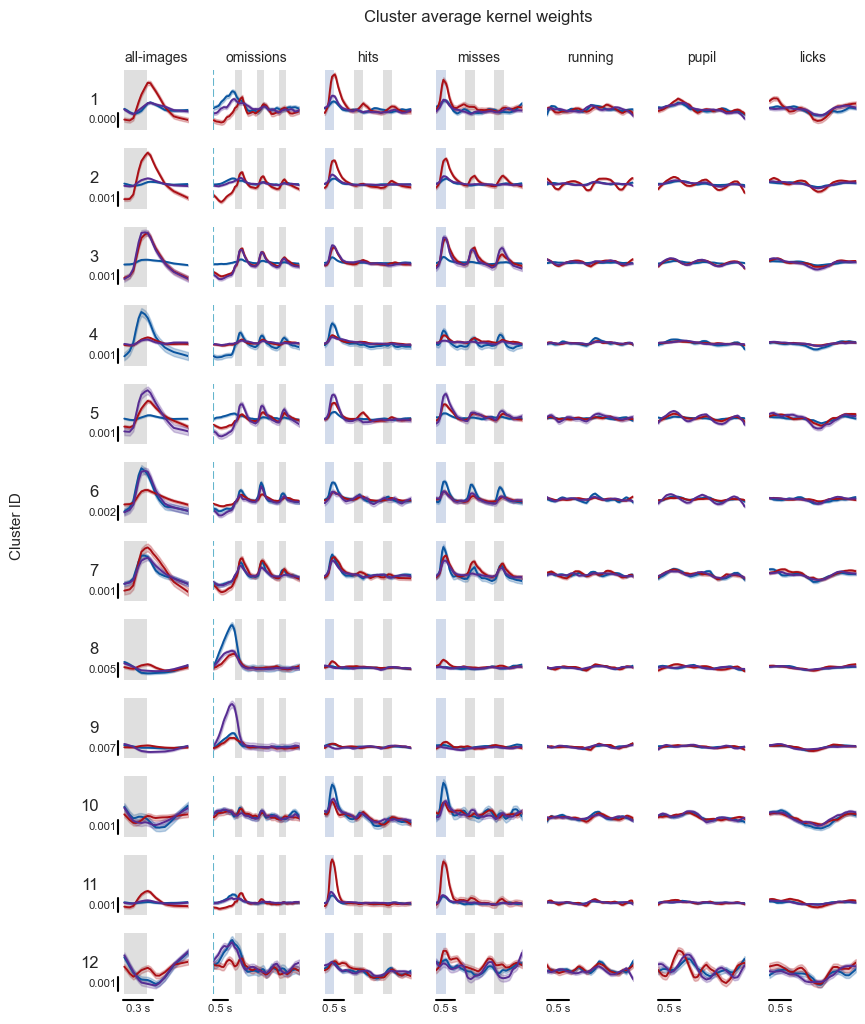

In [6]:
kernels_for_overlay_plot = ['all-images', 'omissions', 'hits', 'misses', 'running', 'pupil', 'licks']

fig, axes = plotting.plot_cluster_kernel_overlays_by_experience(
    weights_df,
    run_params,
    kernels_to_plot=None,
    linewidth=1.4,
    share_y_across="row",
    cell_type=None,
    show_all_clusters=False,
    min_cluster_fraction=0,
    remove_outliers=True,
)
plt.show()

Separate plot per cell type:

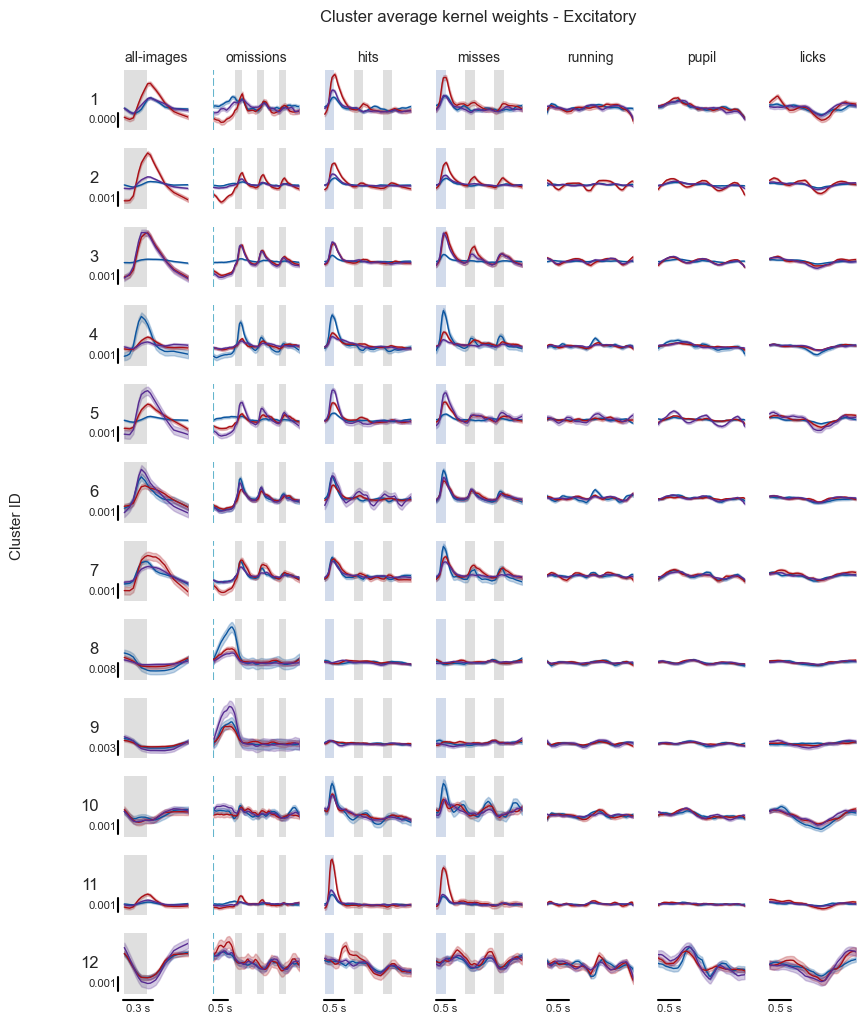

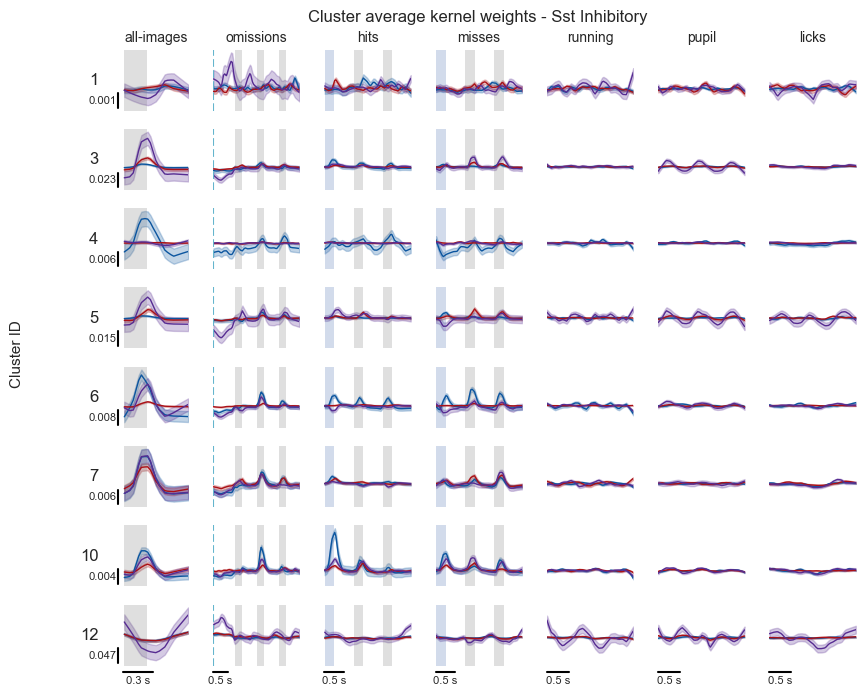

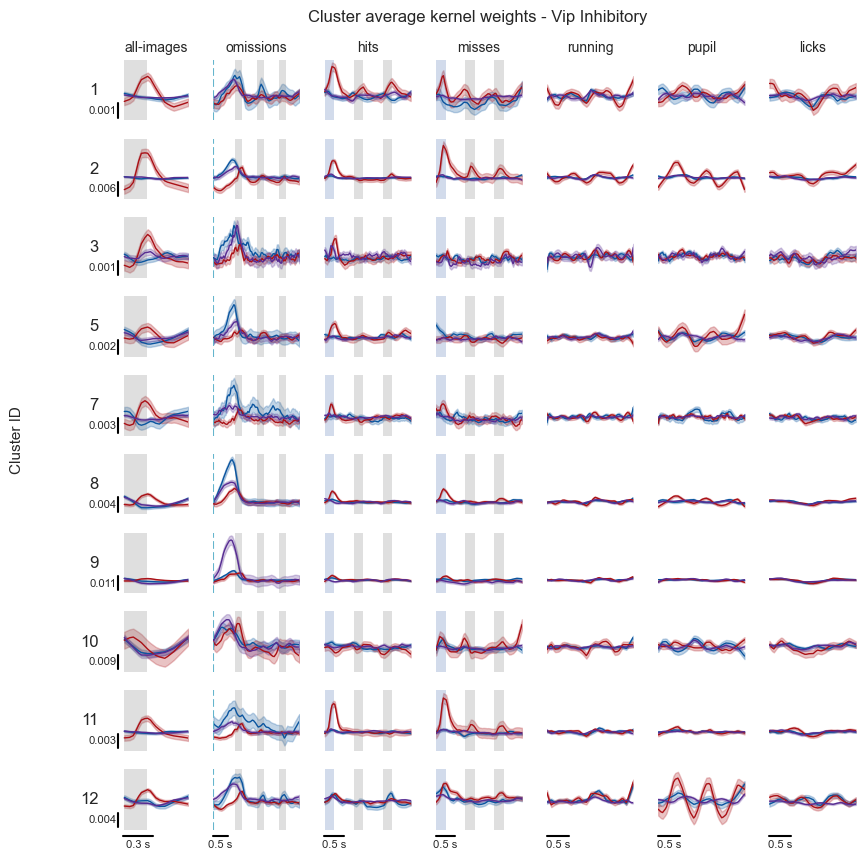

In [7]:
kernels_for_overlay_plot = ['all-images', 'omissions', 'hits', 'misses', 'running', 'pupil', 'licks']

for cell_type in cell_types:
    fig, axes = plotting.plot_cluster_kernel_overlays_by_experience(
        weights_df,
        run_params,
        kernels_to_plot=None,
        linewidth=1,
        share_y_across="row",
        cell_type=cell_type,
        show_all_clusters=False,
        min_cluster_fraction=0.04,
        remove_outliers=True,
    )
    plt.show()

## Kernel heatmaps

Note: `prepare_and_plot_concatenated_image_kernels` does **no** outlier removal — every cell in each cluster appears as a row. This makes the heatmaps a useful reference for seeing how many cells the trace-based methods drop.

Prepared 'concatenated_image': plotted length=185, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

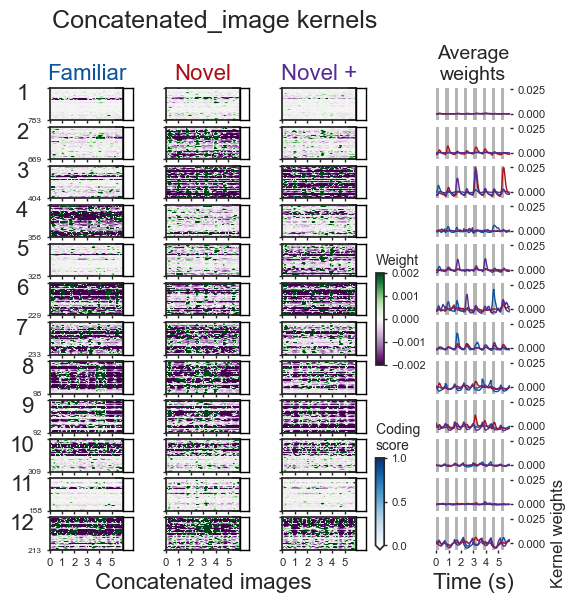

In [8]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = plotting.prepare_and_plot_concatenated_image_kernels(
    kernel_names=['concatenated_images'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Concatenated images',
    suptitle=None,
    plot=True,
    split_by_cell_type=False,
)

Prepared 'concatenated_image': plotted length=185, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

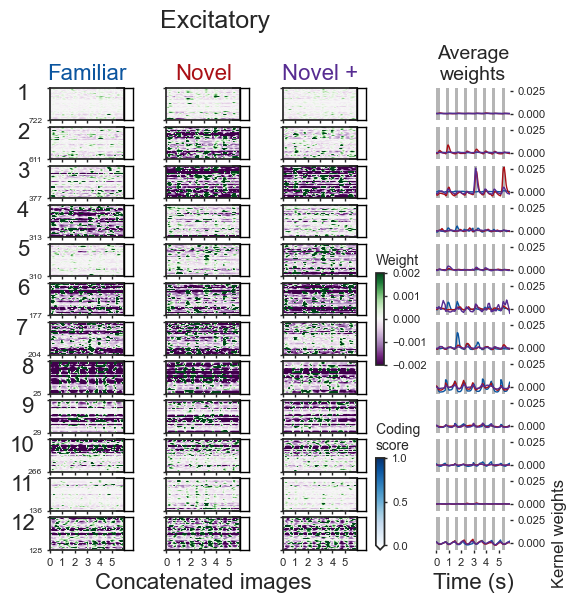

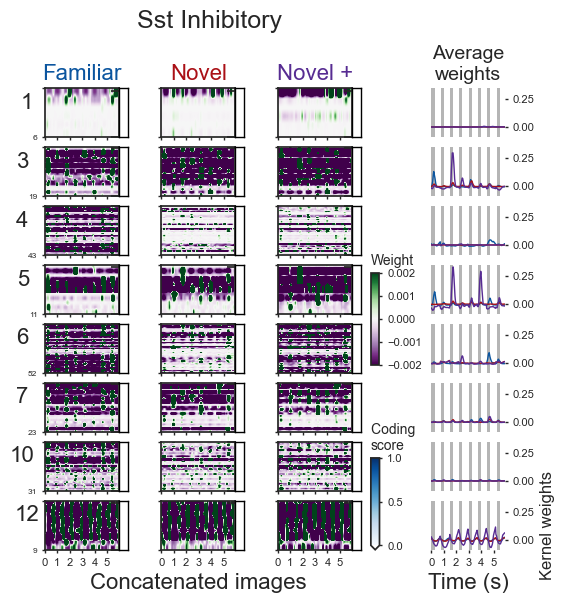

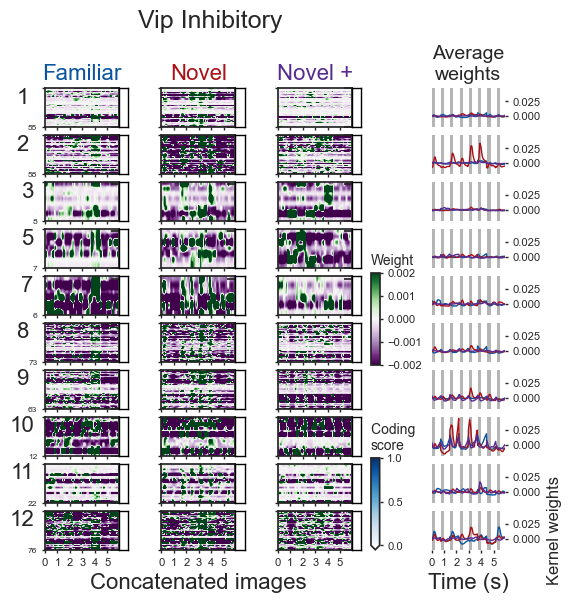

In [9]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = plotting.prepare_and_plot_concatenated_image_kernels(
    kernel_names=['concatenated_images'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Concatenated images',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'omissions': plotted length=93, kept 3872/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

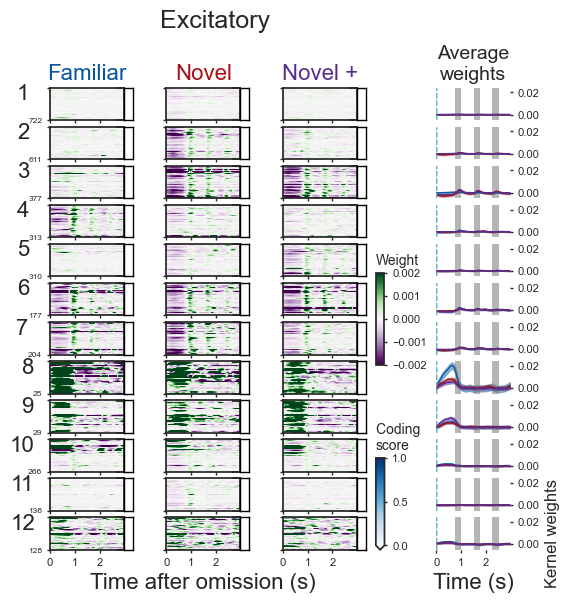

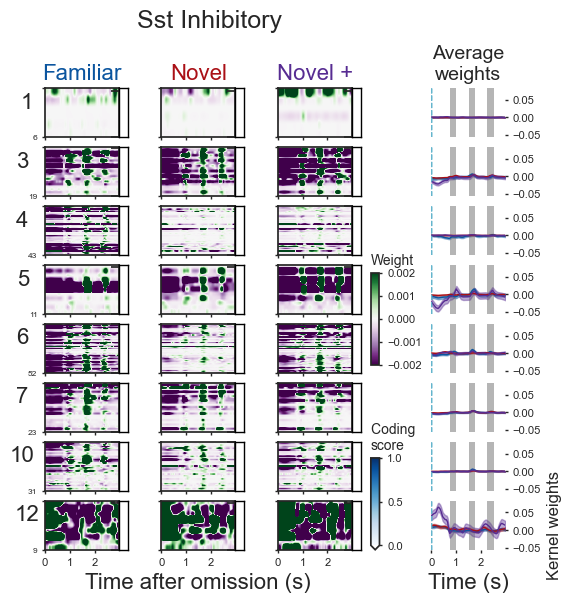

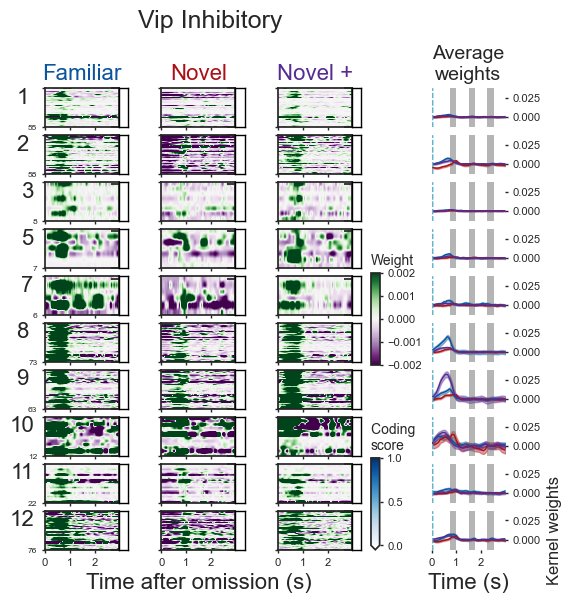

In [10]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = plotting.prepare_and_plot_concatenated_image_kernels(
    kernel_names=['omissions'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Time after omission (s)',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'hits_misses': plotted length=140, kept 3857/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

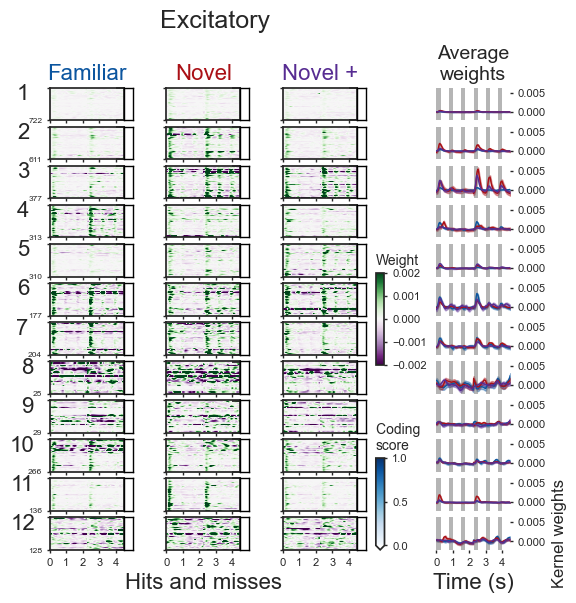

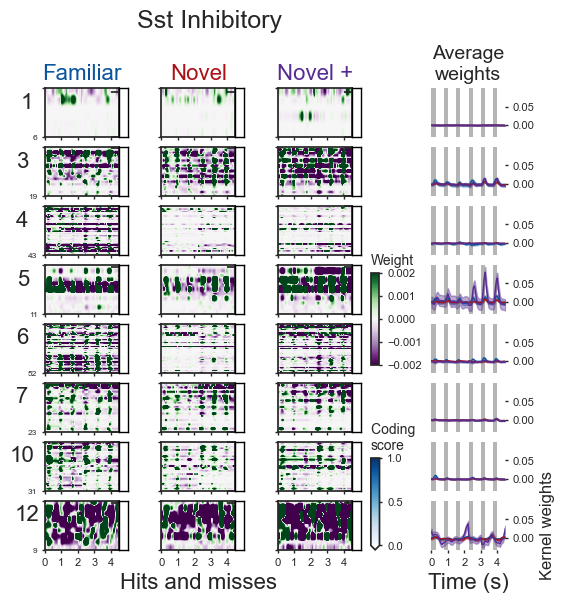

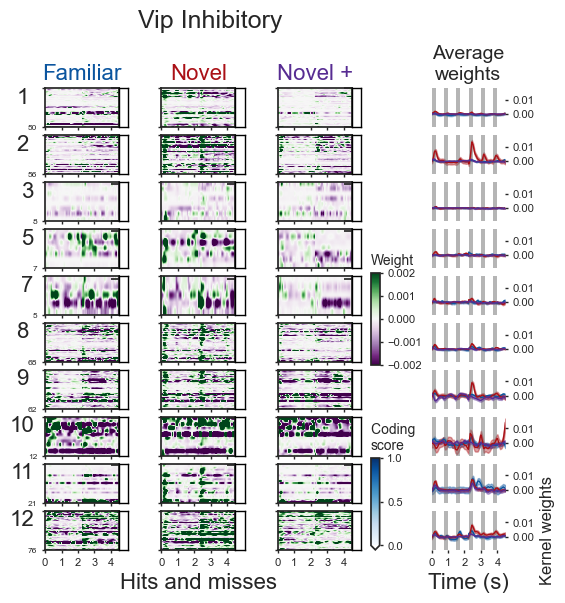

In [11]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = plotting.prepare_and_plot_concatenated_image_kernels(
    kernel_names=['hits', 'misses'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Hits and misses',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

Prepared 'licks_running_pupil': plotted length=186, kept 3829/3901 cells with complete experience coverage.


/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization/ophys/glm_example_plots.py:2941: RuntimeWarning: invalid value encountered in sqrt
  coding_scores = np.sqrt(coding_scores[:, np.newaxis] * -1)
/Users/marinag/Documents/Code/visual_behavior_analysis/visual_behavior/visualization

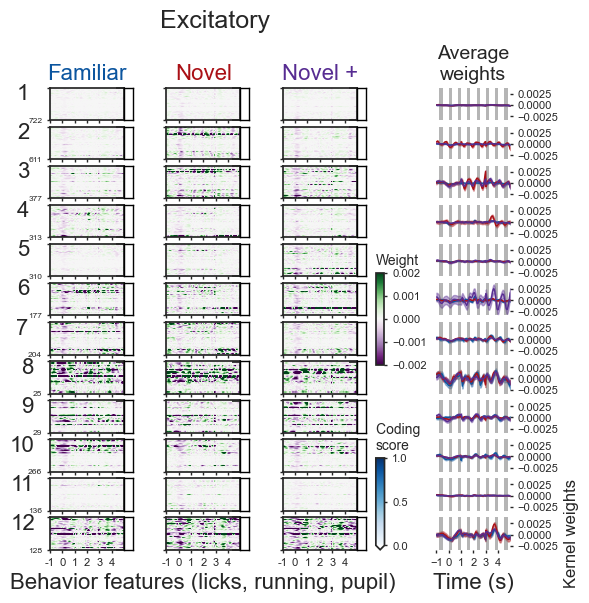

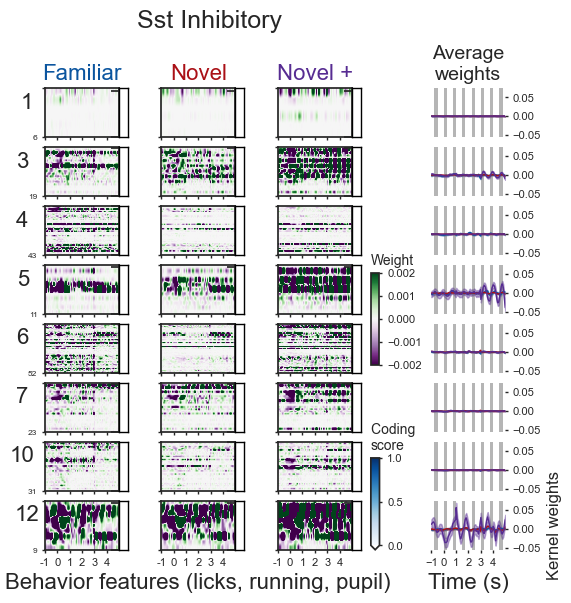

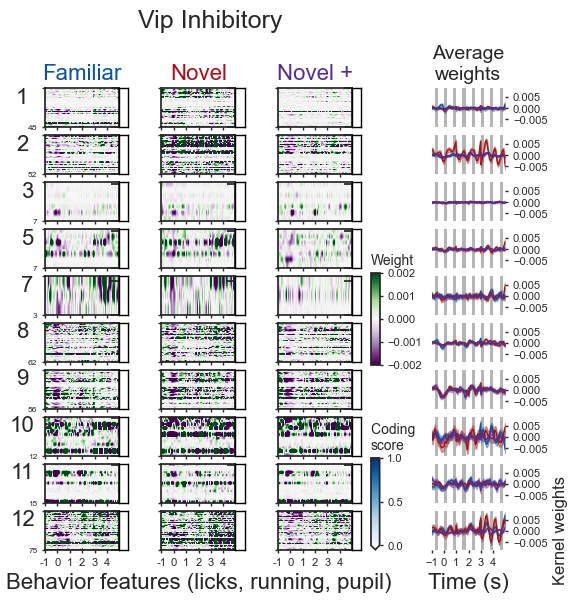

In [12]:
# Example usage: build data + plot all cells in one call
reformatted_weights_df, melted_weights_df, run_params_tmp = plotting.prepare_and_plot_concatenated_image_kernels(
    kernel_names=['licks', 'running', 'pupil'],
    weights_df=weights_df,
    run_params=run_params,
    experience_levels=experience_levels,
    row_condition='cluster_id',
    col_condition='experience_level',
    vmax=0.002,
    xlabel='Behavior features (licks, running, pupil)',
    suptitle=None,
    plot=True,
    split_by_cell_type=True,
)

## Coding scores & average responses

`plot_cluster_properties_combined` filters with `processing.remove_outliers` (percentile-based, on scalar mean_response & mean_baseline).

All cre lines combined:

12


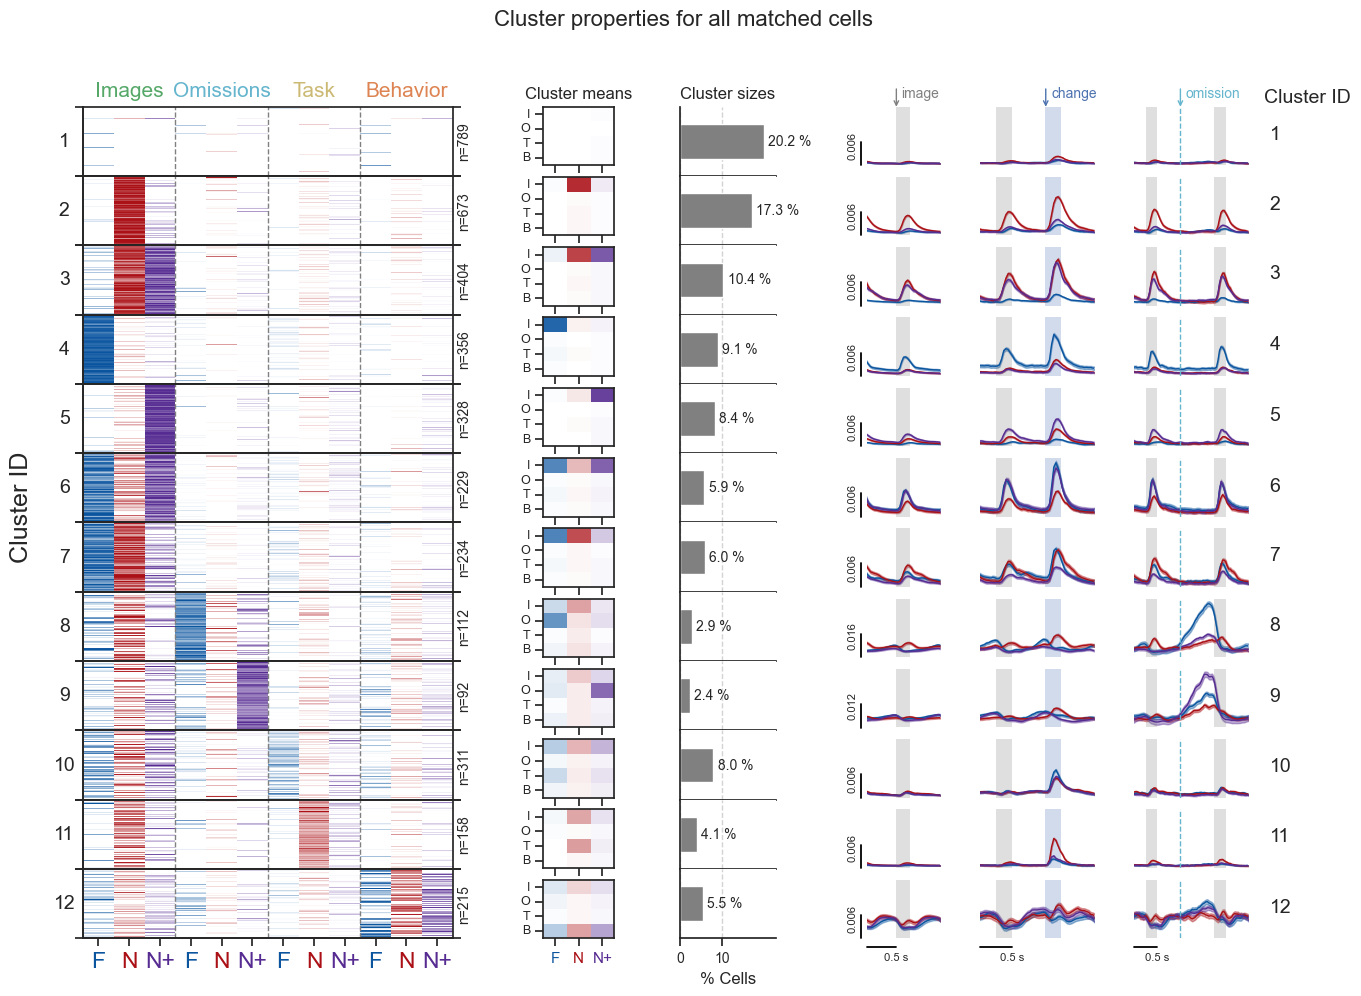

In [13]:
# All cre lines combined
tmp = cluster_meta.copy()
tmp['cre_line'] = 'all'

plotting.plot_cluster_properties_combined(
    tmp,
    feature_matrix,
    'all',
    image_mdf,
    change_mdf,
    omission_mdf,
    save_dir=save_dir)


By individual cre line:

12
6
7


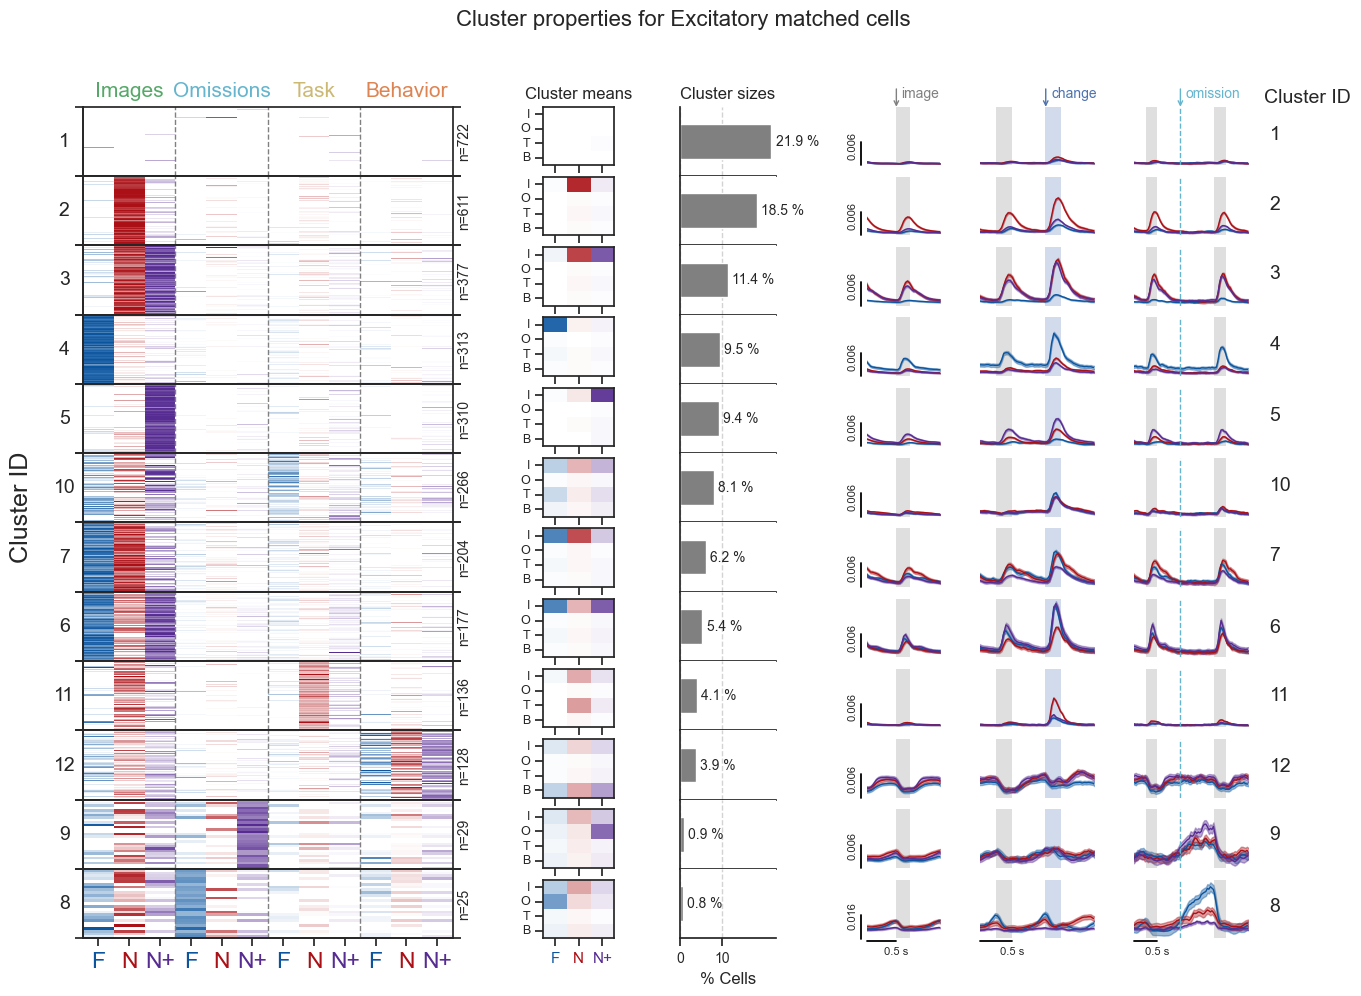

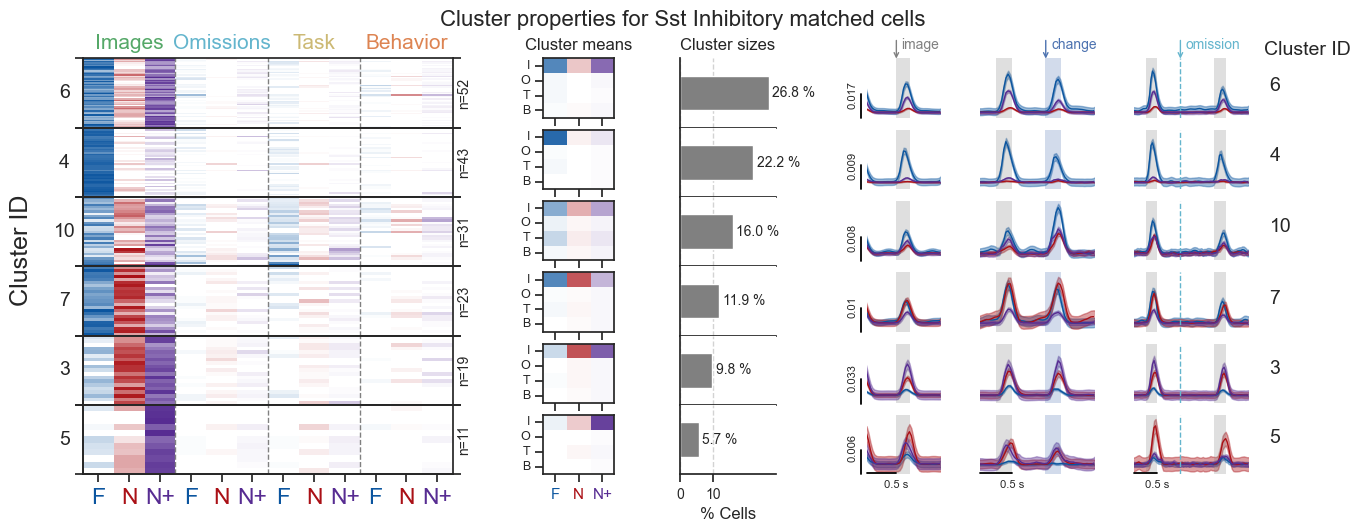

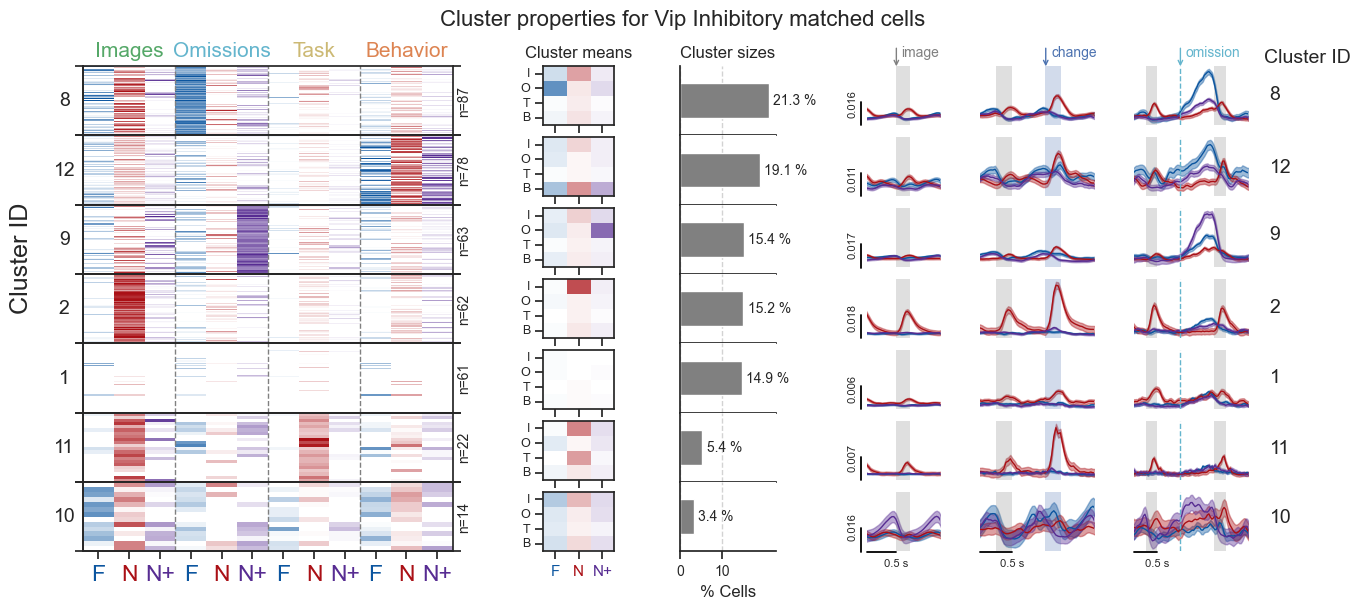

In [14]:

# By individual cre line
for cre_line in cre_lines:
    plotting.plot_cluster_properties_combined(
        cluster_meta,
        feature_matrix,
        cre_line,
        image_mdf,
        change_mdf,
        omission_mdf,
        save_dir=save_dir,
        sort_by='cluster_size')


## Mean cluster response profiles

`plot_mean_cluster_response_profiles` filters with `_drop_outlier_traces` (MAD-based, on the peak amplitude of each cell's mean response trace; `outlier_threshold=5`).

(<Figure size 560x420 with 12 Axes>,
 array([[<Axes: title={'center': 'Cluster 2'}>,
         <Axes: title={'center': 'Cluster 3'}>,
         <Axes: title={'center': 'Cluster 4'}>,
         <Axes: title={'center': 'Cluster 10'}>],
        [<Axes: title={'center': 'Cluster 6'}>,
         <Axes: title={'center': 'Cluster 3'}>,
         <Axes: title={'center': 'Cluster 4'}>,
         <Axes: title={'center': 'Cluster 10'}>],
        [<Axes: title={'center': 'Cluster 2'}>,
         <Axes: title={'center': 'Cluster 9'}>,
         <Axes: title={'center': 'Cluster 8'}>,
         <Axes: title={'center': 'Cluster 11'}>]], dtype=object))

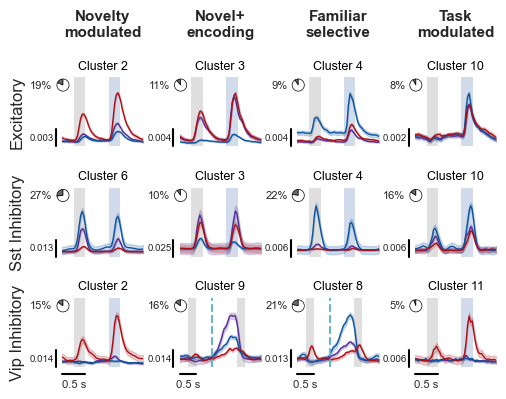

In [15]:
plotting.plot_mean_cluster_response_profiles(
    image_mdf,
    change_mdf,
    omission_mdf,
    linewidth=1,
    x_sb_seconds=0.5,
    outlier_threshold=5,
)


## Evaluating the two outlier-removal methods

The two functions filter cells in **fundamentally different ways**:

**Method A — `plot_mean_cluster_response_profiles` → `_drop_outlier_traces`**
- Quantity: peak absolute amplitude of each cell's *mean response trace* (`max(|trace|)`).
- Statistic: MAD-based robust z-score. Keep if `peak <= median + threshold * 1.4826 * MAD`.
- Threshold: `outlier_threshold=5` (≈5 robust SDs above the median).
- Scope: computed **separately for each (cell_type, cluster_id, experience_level)** group.
  The median/MAD adapt to each cluster's local distribution, and a cell can be kept in one
  experience level but dropped in another.

**Method B — `plot_cluster_properties_combined` → `processing.remove_outliers`**
- Quantity: scalar `mean_response` AND `mean_baseline`.
- Statistic: percentile threshold (99.8th) computed **per cre line**.
- Rule: a cell is an outlier only if `mean_response > p99.8` **AND** `mean_baseline > p99.8`
  (so cells with a big evoked response but normal baseline are *not* removed — this mostly
  targets tonically high / saturated cells).
- Plus a hard-coded list of 9 known-bad cells, always removed.
- Scope: removes the cell from the **entire dataframe** (every cluster & experience level).

Implications to watch for:
- Method A is **relative** and **local**: in a small cluster where most cells are quiet and a
  few are genuine strong responders, the MAD is tiny, so real responders can exceed
  `5*1.4826*MAD` and get dropped as "outliers" — i.e. it can remove meaningful signal.
- Method B is **absolute** and **conservative**: the AND-condition + 99.8th percentile removes
  very few cells (only globally extreme ones), so it rarely touches real signal but may leave
  in moderately large responders that still distort a small-cluster mean.

The cells below quantify and visualize the difference.

In [16]:
# --- Diagnostic helpers: replicate each method's drop logic, tracking cell IDs ---
# Assumptions:
#   * each row of *_mdf is one cell (cell_specimen_id) at one experience_level
#   * columns present: cell_specimen_id, cre_line, cell_type, cluster_id,
#     experience_level, mean_trace, mean_response, mean_baseline
import numpy as np, pandas as pd

def method_A_drops(mdf, outlier_threshold=5):
    """Method A (MAD on trace peak), applied per (cell_type, cluster_id, experience_level).
    Returns a df of rows it would DROP, with the group keys + peak value."""
    rows = []
    grp = mdf[mdf[['cluster_id','cell_type','experience_level']].notna().all(axis=1)]
    for (ct, cl, exp), g in grp.groupby(['cell_type','cluster_id','experience_level']):
        traces = [np.asarray(t) for t in g['mean_trace'].values
                  if t is not None and not (isinstance(t, float) and np.isnan(t))]
        if not traces:
            continue
        valid = g[[t is not None and not (isinstance(t, float) and np.isnan(t))
                   for t in g['mean_trace'].values]].copy()
        peak = np.array([np.nanmax(np.abs(np.asarray(t))) for t in valid['mean_trace'].values])
        med = np.median(peak); mad = np.median(np.abs(peak - med))
        if mad <= 0:
            continue
        keep = peak <= med + outlier_threshold * 1.4826 * mad
        dropped = valid.loc[~keep, ['cell_specimen_id','cre_line','cell_type',
                                    'cluster_id','experience_level']].copy()
        dropped['peak_abs'] = peak[~keep]
        rows.append(dropped)
    return pd.concat(rows, ignore_index=True) if rows else pd.DataFrame(
        columns=['cell_specimen_id','cre_line','cell_type','cluster_id','experience_level','peak_abs'])

def method_B_drops(mdf, threshold_percentile=99.8):
    """Method B (percentile on mean_response AND mean_baseline), per cre line, + hard-coded bad cells.
    Returns the set of cell_specimen_ids removed globally."""
    bad_cells = [1120091750,1120094237,1086580238,1086551540,1086553602,
                 1086514682,1086515397,1086673279,1086529704]
    outliers = set(bad_cells)
    for cre in mdf.cre_line.unique():
        c = mdf[mdf.cre_line == cre]
        r_thr = np.percentile(c.mean_response.values, threshold_percentile)
        b_thr = np.percentile(c.mean_baseline.values, threshold_percentile)
        outliers |= set(c[(c.mean_response > r_thr) & (c.mean_baseline > b_thr)]
                        .cell_specimen_id.unique())
    return outliers

# Run on change_mdf as an example (swap for image_mdf / omission_mdf as needed)
mdf = change_mdf
A = method_A_drops(mdf, outlier_threshold=5)
B = method_B_drops(mdf, threshold_percentile=99.8)

A_cells = set(A.cell_specimen_id.unique())
n_total = mdf.cell_specimen_id.nunique()
print(f"Total cells: {n_total}")
print(f"Method A drops {len(A)} (cell x experience) instances, "
      f"{len(A_cells)} unique cells ({100*len(A_cells)/n_total:.1f}%)")
print(f"Method B drops {len(B)} unique cells ({100*len(B)/n_total:.1f}%)")
print(f"Overlap (dropped by both): {len(A_cells & B)} cells")
print(f"Dropped by A only: {len(A_cells - B)} | by B only: {len(B - A_cells)}")


Total cells: 3897
Method A drops 683 (cell x experience) instances, 447 unique cells (11.5%)
Method B drops 19 unique cells (0.5%)
Overlap (dropped by both): 18 cells
Dropped by A only: 429 | by B only: 1


In [17]:
# Per-cluster breakdown: how many cells each method drops in each (cell_type, cluster)
per_cluster_A = (A.drop_duplicates(['cell_specimen_id','cell_type','cluster_id'])
                  .groupby(['cell_type','cluster_id']).size().rename('A_dropped'))
totals = (mdf.drop_duplicates('cell_specimen_id')
            .groupby(['cell_type','cluster_id']).size().rename('n_cells'))
B_df = mdf[mdf.cell_specimen_id.isin(B)].drop_duplicates('cell_specimen_id')
per_cluster_B = B_df.groupby(['cell_type','cluster_id']).size().rename('B_dropped')

summary = pd.concat([totals, per_cluster_A, per_cluster_B], axis=1).fillna(0).astype(int)
summary['A_frac'] = (summary.A_dropped / summary.n_cells).round(3)
summary['B_frac'] = (summary.B_dropped / summary.n_cells).round(3)
summary.sort_values('A_frac', ascending=False)


n_cells  A_dropped  B_dropped  A_frac  B_frac
cell_type      cluster_id                                               
Sst Inhibitory 5                11          4          0   0.364   0.000
Vip Inhibitory 2                62         17          1   0.274   0.016
               1                60         14          0   0.233   0.000
Sst Inhibitory 4                43         10          2   0.233   0.047
Vip Inhibitory 11               22          5          1   0.227   0.045
Sst Inhibitory 12                9          2          2   0.222   0.222
               7                23          5          0   0.217   0.000
               6                52         11          1   0.212   0.019
               3                19          4          0   0.211   0.000
Vip Inhibitory 9                63         11          0   0.175   0.000
               12               75         13          1   0.173   0.013
Sst Inhibitory 1                 6          1          1   0.167   0.167
Excitatory     8                25          4          0   0.160   0.000
               10              266         42          1   0.158   0.004
               3               377         52          3   0.138   0.008
               9                29          4          0   0.138   0.000
Sst Inhibitory 10               31          4          0   0.129   0.000
Excitatory     4               313         34          1   0.109   0.003
               6               177         19          1   0.107   0.006
Vip Inhibitory 8                87          9          0   0.103   0.000
Excitatory     5               310         31          1   0.100   0.003
               11              136         12          0   0.088   0.000
               12              128         11          0   0.086   0.000
               2               611         51          0   0.083   0.000
               1               722         60          0   0.083   0.000
               7               204         16          2   0.078   0.010
Vip Inhibitory 10               14          1          1   0.071   0.071
               5                 7          0          0   0.000   0.000
               7                 7          0          0   0.000   0.000
               3                 8          0          0   0.000   0.000

### Visualize kept vs. dropped traces

For a chosen (cell_type, cluster_id, experience_level), overlay the traces each method keeps vs.
drops. If the "dropped" traces look like genuine, structured responses (clean stimulus-locked
transients) rather than noisy/saturated artifacts, the filter is removing meaningful signal.

In [18]:
import matplotlib.pyplot as plt

def plot_kept_vs_dropped(mdf, cell_type, cluster_id, experience_level,
                         method='A', outlier_threshold=5, threshold_percentile=99.8):
    g = mdf[(mdf.cell_type==cell_type) & (mdf.cluster_id==cluster_id) &
            (mdf.experience_level==experience_level)].copy()
    g = g[[t is not None and not (isinstance(t,float) and np.isnan(t))
           for t in g['mean_trace'].values]]
    ts = np.asarray(g['trace_timestamps'].values[0])
    if method == 'A':
        peak = np.array([np.nanmax(np.abs(np.asarray(t))) for t in g['mean_trace'].values])
        med = np.median(peak); mad = np.median(np.abs(peak-med))
        keep = peak <= med + outlier_threshold*1.4826*mad if mad>0 else np.ones(len(g),bool)
    else:  # method B membership
        B = method_B_drops(mdf, threshold_percentile)
        keep = ~g.cell_specimen_id.isin(B).values

    fig, axes = plt.subplots(1, 2, figsize=(10,4), sharey=True)
    for t in g['mean_trace'].values[keep]:
        axes[0].plot(ts, np.asarray(t), color='gray', alpha=0.4, lw=0.8)
    for t in g['mean_trace'].values[~keep]:
        axes[1].plot(ts, np.asarray(t), color='crimson', alpha=0.7, lw=1.0)
    axes[0].set_title(f"KEPT (n={int(keep.sum())})")
    axes[1].set_title(f"DROPPED (n={int((~keep).sum())})")
    fig.suptitle(f"Method {method} | {cell_type} cluster {cluster_id} | {experience_level}")
    plt.tight_layout(); plt.show()

# Example — pick a cluster with high A_frac from the summary table above:
# plot_kept_vs_dropped(change_mdf, 'Vip Inhibitory', 11, 'Novel', method='A')
